<a href="https://colab.research.google.com/github/kosebaris1/MACHINE_LEARNING/blob/DBN/DBN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ham veri şekilleri:
X_train: (60000, 28, 28, 1)
X_test : (10000, 28, 28, 1)

Kullanılan alt küme:
X_train_small: (30000, 784)
X_test_small : (5000, 784)


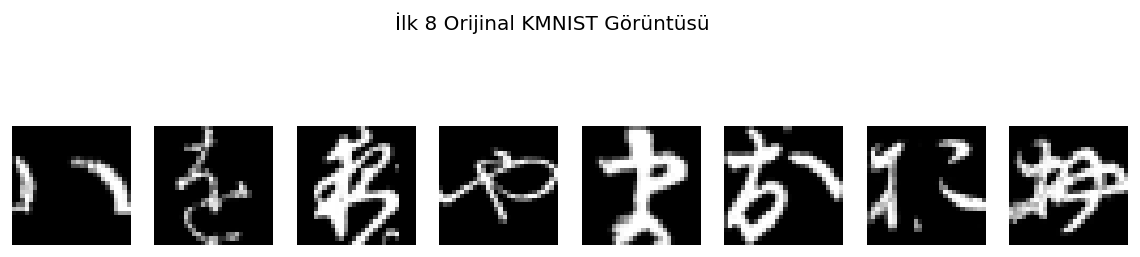


RBM1 eğitiliyor (784 -> 256)...
H1_train şekli: (30000, 256)

RBM2 eğitiliyor (256 -> 128)...
H2_train şekli: (30000, 128)

DOĞRULUK (Accuracy) SONUÇLARI (MLP Sınıflandırıcı)
Ham X  accuracy  : 0.8784
RBM1 H1 accuracy : 0.8926
RBM2 H2 accuracy : 0.8696

=== Classification Report (H2 – DBN en üst temsil) ===

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       492
           1       0.89      0.84      0.86       505
           2       0.78      0.86      0.82       504
           3       0.89      0.96      0.92       483
           4       0.81      0.87      0.84       510
           5       0.90      0.85      0.88       521
           6       0.88      0.90      0.89       507
           7       0.91      0.80      0.85       486
           8       0.84      0.92      0.88       496
           9       0.91      0.87      0.89       496

    accuracy                           0.87      5000
   macro avg       0.87      0.87      

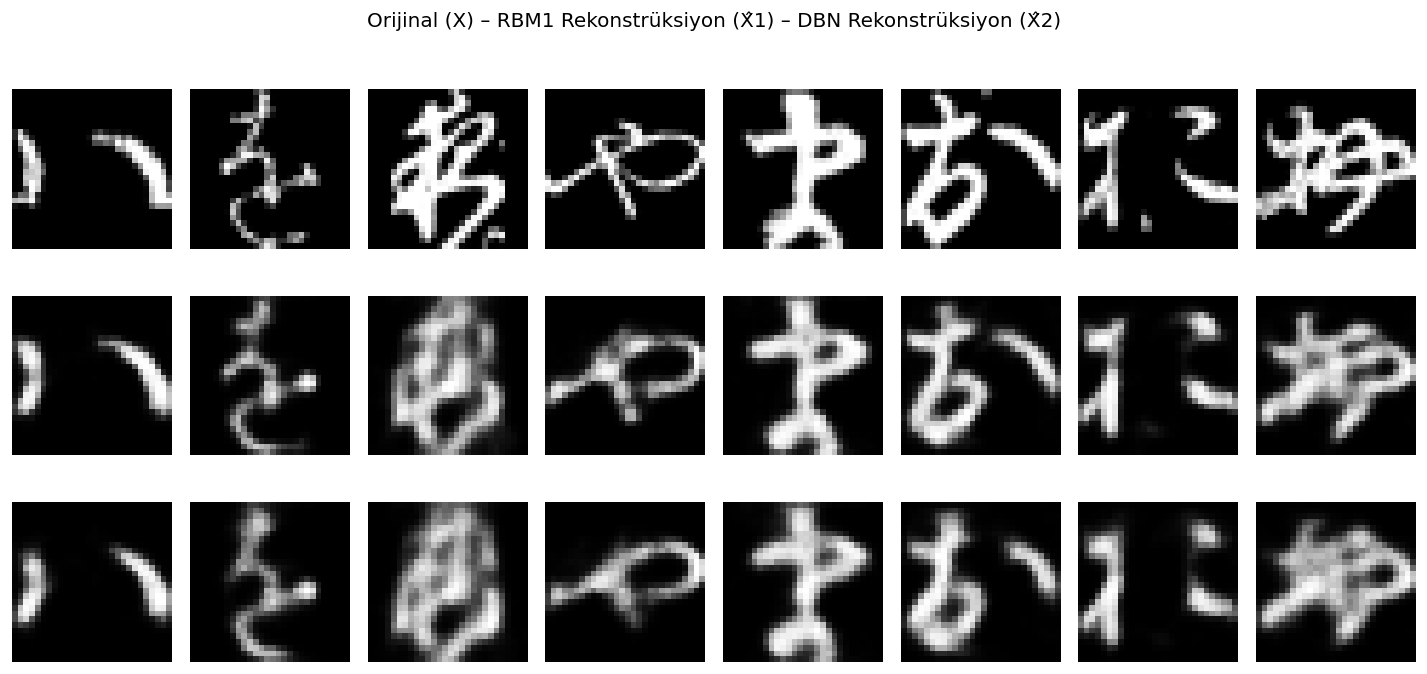


TÜM ÇIKTILAR BAŞARIYLA ÜRETİLDİ ✔


In [3]:

import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import BernoulliRBM, MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Matplotlib ayarı
plt.rcParams["figure.dpi"] = 120

# ============================================================
# 1) KMNIST VERİ SETİNİ YÜKLE
# ============================================================
ds_train, ds_test = tfds.load(
    "kmnist",
    split=["train", "test"],
    as_supervised=True
)

def to_numpy(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = to_numpy(ds_train)
X_test, y_test = to_numpy(ds_test)

print("Ham veri şekilleri:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# ============================================================
# 2) Normalize + Flatten (28x28 -> 784)
# ============================================================
X_train = (X_train / 255.0).reshape(len(X_train), -1)
X_test  = (X_test  / 255.0).reshape(len(X_test),  -1)

# Eğitim süresini kısaltmak için alt küme
X_train_small = X_train[:30000]
y_train_small = y_train[:30000]

X_test_small = X_test[:5000]
y_test_small = y_test[:5000]

print("\nKullanılan alt küme:")
print("X_train_small:", X_train_small.shape)
print("X_test_small :", X_test_small.shape)

# ============================================================
# 3) İlk 8 orijinal görüntüyü göster
# ============================================================
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(X_test_small[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("İlk 8 Orijinal KMNIST Görüntüsü")
plt.show()

# ============================================================
# 4) RBM1 ve RBM2 (DBN Mimarisi)
# ============================================================
# Daha iyi temsil için iterasyon ve learning rate'i artırdık
rbm1 = BernoulliRBM(
    n_components=256,
    learning_rate=0.05,
    n_iter=40,
    batch_size=64,
    verbose=0
)

rbm2 = BernoulliRBM(
    n_components=128,
    learning_rate=0.05,
    n_iter=40,
    batch_size=64,
    verbose=0
)

print("\nRBM1 eğitiliyor (784 -> 256)...")
rbm1.fit(X_train_small)
H1_train = rbm1.transform(X_train_small)
H1_test  = rbm1.transform(X_test_small)
print("H1_train şekli:", H1_train.shape)

print("\nRBM2 eğitiliyor (256 -> 128)...")
rbm2.fit(H1_train)
H2_train = rbm2.transform(H1_train)
H2_test  = rbm2.transform(H1_test)
print("H2_train şekli:", H2_train.shape)

# ============================================================
# 5) MLP Sınıflandırıcı (aynı yapı X, H1, H2 için)
# ============================================================
def make_mlp():
    return MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        batch_size=128,
        max_iter=25,
        early_stopping=True,
        n_iter_no_change=3,
        verbose=False
    )

# --- X üzerinde ---
mlp_X = make_mlp()
mlp_X.fit(X_train_small, y_train_small)
y_pred_X = mlp_X.predict(X_test_small)

# --- H1 üzerinde ---
mlp_H1 = make_mlp()
mlp_H1.fit(H1_train, y_train_small)
y_pred_H1 = mlp_H1.predict(H1_test)

# --- H2 üzerinde (DBN en üst katman) ---
mlp_H2 = make_mlp()
mlp_H2.fit(H2_train, y_train_small)
y_pred_H2 = mlp_H2.predict(H2_test)

# ============================================================
# 6) DOĞRULUK (ACCURACY) + RAPORLAR
# ============================================================
acc_X  = accuracy_score(y_test_small, y_pred_X)
acc_H1 = accuracy_score(y_test_small, y_pred_H1)
acc_H2 = accuracy_score(y_test_small, y_pred_H2)

print("\n================================================")
print("DOĞRULUK (Accuracy) SONUÇLARI (MLP Sınıflandırıcı)")
print(f"Ham X  accuracy  : {acc_X:.4f}")
print(f"RBM1 H1 accuracy : {acc_H1:.4f}")
print(f"RBM2 H2 accuracy : {acc_H2:.4f}")
print("================================================\n")

print("=== Classification Report (H2 – DBN en üst temsil) ===\n")
print(classification_report(y_test_small, y_pred_H2))

print("=== Confusion Matrix (H2) ===\n")
print(confusion_matrix(y_test_small, y_pred_H2))

# ============================================================
# 7) RBM RECONSTRUCTION FONKSİYONLARI
# ============================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def rbm_reconstruct_visible(rbm, H):
    """
    Gizli katmandan (H) tekrar görünür katmana (X̂) rekonstrüksiyon.
    X̂ = sigmoid(H * W + b_v)
    """
    return sigmoid(H @ rbm.components_ + rbm.intercept_visible_)

def rbm_reconstruct_hidden(rbm, V):
    """
    Görünür katmandan gizli katmana geçiş (kontrol için kullanılabilir).
    H = sigmoid(V * W^T + b_h)
    """
    return sigmoid(V @ rbm.components_.T + rbm.intercept_hidden_)

# RBM1 rekonstrüksiyon: X -> H1 -> X̂1
X_recon_1 = rbm_reconstruct_visible(rbm1, H1_test)

# DBN rekonstrüksiyon:
# X -> H1 -> H2 -> H1̂ -> X̂2
H1_recon = rbm_reconstruct_visible(rbm2, H2_test)
X_recon_2 = rbm_reconstruct_visible(rbm1, H1_recon)

# ============================================================
# 8) ORİJİNAL vs RBM1 vs DBN GÖRSELLERİ
# ============================================================
plt.figure(figsize=(12, 6))

for i in range(8):

    # 1. satır: Orijinal
    plt.subplot(3, 8, i+1)
    plt.imshow(X_test_small[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    # 2. satır: RBM1 Rekonstrüksiyon (X̂1)
    plt.subplot(3, 8, i+1+8)
    plt.imshow(X_recon_1[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("RBM1")

    # 3. satır: DBN Rekonstrüksiyon (X̂2)
    plt.subplot(3, 8, i+1+16)
    plt.imshow(X_recon_2[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("DBN")

plt.suptitle("Orijinal (X) – RBM1 Rekonstrüksiyon (X̂1) – DBN Rekonstrüksiyon (X̂2)")
plt.tight_layout()
plt.show()

print("\nTÜM ÇIKTILAR BAŞARIYLA ÜRETİLDİ ✔")
